In [77]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import os

In [78]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/sanjeethpekumar/classification/test_set",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=64
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/sanjeethpekumar/classification/test_set",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=64
)

Found 2023 files belonging to 2 classes.
Using 1619 files for training.
Found 2023 files belonging to 2 classes.
Using 404 files for validation.


In [79]:
class_names = train_ds.class_names
print(class_names)

['cats', 'dogs']


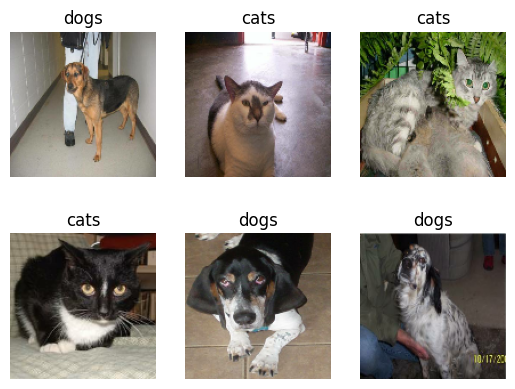

In [80]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [81]:
normalization_layer = layers.Rescaling(1./255)

In [82]:
model = keras.Sequential([
    
    layers.Input(shape=(128, 128, 3)),   

    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [83]:
for images, labels in train_ds.take(1):
    model(images)

In [84]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [85]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.4992 - loss: 0.7609 - val_accuracy: 0.4901 - val_loss: 0.6934
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5020 - loss: 0.6926 - val_accuracy: 0.4926 - val_loss: 0.6886
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5820 - loss: 0.6697 - val_accuracy: 0.6411 - val_loss: 0.6276
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6848 - loss: 0.5977 - val_accuracy: 0.6658 - val_loss: 0.6381
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7279 - loss: 0.5571 - val_accuracy: 0.6584 - val_loss: 0.6125
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7605 - loss: 0.5091 - val_accuracy: 0.6683 - val_loss: 0.6259
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7740 - loss: 0.5004 - val_accuracy: 0.6931 - val_loss: 0.6004
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8056 - loss: 0.4296 - val_accuracy: 0.7054 - 

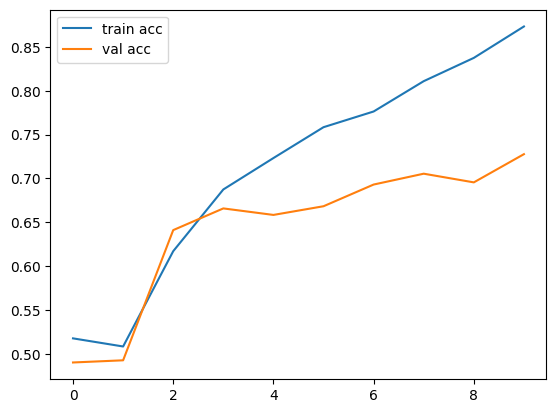

In [87]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [88]:
# Model shows overfitting as training accuracy increases significantly while validation accuracy saturates.
# need to add dropout layers to solve overfitting 

In [89]:
model1 = keras.Sequential([
    
    layers.Input(shape=(128,128,3)),
    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),   

    layers.Dense(1, activation='sigmoid')
])

In [90]:
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [91]:
history2 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.5297 - loss: 0.7433 - val_accuracy: 0.4901 - val_loss: 0.6971
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5438 - loss: 0.6804 - val_accuracy: 0.5965 - val_loss: 0.6660
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6046 - loss: 0.6474 - val_accuracy: 0.6163 - val_loss: 0.6386
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6898 - loss: 0.6060 - val_accuracy: 0.6312 - val_loss: 0.6288
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7204 - loss: 0.5495 - val_accuracy: 0.6683 - val_loss: 0.6032
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7244 - loss: 0.5393 - val_accuracy: 0.6832 - val_loss: 0.5811
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7444 - loss: 0.5202 - val_accuracy: 0.7030 - val_loss: 0.5801
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7750 - loss: 0.4687 - val_accuracy: 0.6906 - 

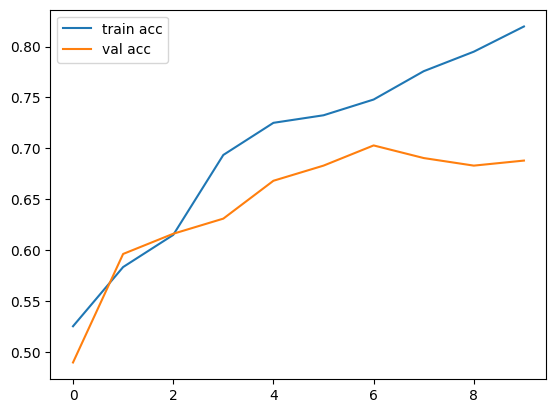

In [92]:
plt.plot(history2.history['accuracy'], label='train acc')
plt.plot(history2.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [93]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [94]:
model3 = keras.Sequential([
    
    layers.Input(shape=(128,128,3)),

    data_augmentation,  

    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [95]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [96]:
history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4836 - loss: 0.7261 - val_accuracy: 0.5817 - val_loss: 0.6919
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5588 - loss: 0.6909 - val_accuracy: 0.5446 - val_loss: 0.6876
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5585 - loss: 0.6862 - val_accuracy: 0.5594 - val_loss: 0.6795
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5968 - loss: 0.6698 - val_accuracy: 0.6188 - val_loss: 0.6614
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6475 - loss: 0.6459 - val_accuracy: 0.6460 - val_loss: 0.6496
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6485 - loss: 0.6390 - val_accuracy: 0.6262 - val_loss: 0.6398
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6652 - loss: 0.6238 - val_accuracy: 0.6782 - val_loss: 0.6295
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6964 - loss: 0.6091 - val_accuracy: 0.6757 - v

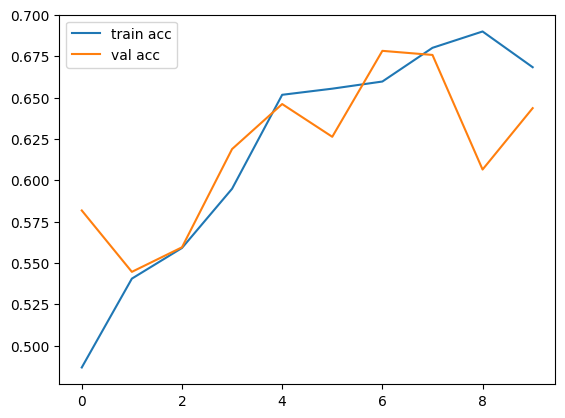

In [97]:
plt.plot(history3.history['accuracy'], label='train acc')
plt.plot(history3.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [98]:
from tensorflow.keras.applications import MobileNetV2

In [99]:
base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  

In [100]:
# Input
inputs = keras.Input(shape=(128,128,3))

# Pass through base model
x = base_model(inputs, training=False)

# Custom layers
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

# Final model
final_model = keras.Model(inputs, outputs)

In [101]:
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 528ms/step - accuracy: 0.5174 - loss: 1.0478 - val_accuracy: 0.5124 - val_loss: 0.8070
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4798 - loss: 0.9456 - val_accuracy: 0.5099 - val_loss: 0.7378
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4936 - loss: 0.8696 - val_accuracy: 0.5025 - val_loss: 0.7181
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4776 - loss: 0.8834 - val_accuracy: 0.5396 - val_loss: 0.7131
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4821 - loss: 0.8495 - val_accuracy: 0.5198 - val_loss: 0.7105


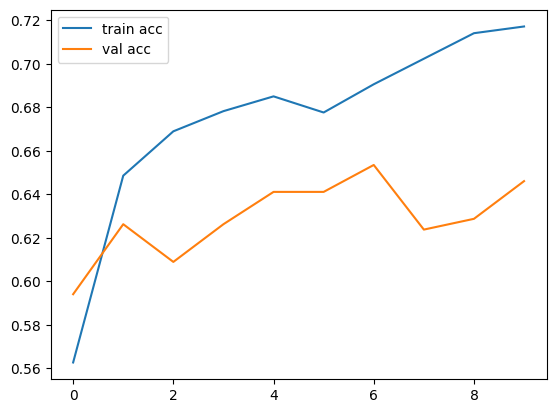

In [102]:
plt.plot(final_history.history['accuracy'], label='train acc')
plt.plot(final_history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [103]:
# I experimented with both custom CNN and transfer learning. MobileNet provided better feature extraction, 
# while I controlled overfitting using dropout and augmentation

In [104]:
# when user will upload image
# Image → Resize → Normalize → Model → Prediction → Label
from tensorflow.keras.preprocessing import image

In [105]:
img = image.load_img("/kaggle/input/datasets/sanjeethpekumar/classification/test_set/cats/cat.4002.jpg", target_size=(128,128))

In [106]:
img_array = image.img_to_array(img)

In [107]:
img_array = img_array / 255.0

In [108]:
import numpy as np
img_array = np.expand_dims(img_array, axis=0)

In [109]:
prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    result = "Dog 🐶"
else:
    result = "Cat 🐱"

print("Raw:", prediction)
print("Result:", result)
print("Confidence:", float(prediction[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
Raw: [[0.01667372]]
Result: Cat 🐱
Confidence: 0.016673723235726357


In [110]:
print(type(final_model))

<class 'keras.src.models.functional.Functional'>


In [111]:
final_model.save("cat_dog_model.keras")